In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
df = pd.read_pickle(
    "../data/user_behavior.pkl"
)

df.head()

,user_id,item_id,category_id,behavior,timestamp
0,1,2268318,2520377,pv,1511544070
1,1,2333346,2520771,pv,1511561733
2,1,2576651,149192,pv,1511572885
3,1,3830808,4181361,pv,1511593493
4,1,4365585,2520377,pv,1511596146


In [14]:
behavior_count = (
    df["behavior"]
    .value_counts()
    .reset_index()
)

behavior_count.columns = [
    "behavior",
    "count"
]

behavior_count

,behavior,count
0,pv,89716264
1,cart,5530446
2,fav,2888258
3,buy,2015839


In [15]:
behavior_count.to_csv(
    "../data/behavior_count.csv",
    index=False,
    encoding="utf-8-sig"
)

In [16]:
user_behavior = (
    df.groupby(
        ["user_id","behavior"]
    )
    .size()
    .unstack(fill_value=0)
)


user_behavior.head()

behavior,buy,cart,fav,pv
user_id,,,,
1,0,0,0,55
2,7,3,7,54
3,0,15,5,33
4,4,13,0,268
5,0,0,0,64


In [17]:
for col in [
    "pv",
    "fav",
    "cart",
    "buy"
]:
    
    if col not in user_behavior.columns:
        user_behavior[col] = 0

In [18]:
user_behavior["score"] = (
    user_behavior["pv"] * 0.1
    +
    user_behavior["fav"] * 1
    +
    user_behavior["cart"] * 2
    +
    user_behavior["buy"] * 5
)

In [19]:
def user_level(score):

    if score >= 20:
        return "高价值用户"

    elif score >= 5:
        return "潜力用户"

    else:
        return "普通用户"



user_behavior["level"] = (
    user_behavior["score"]
    .apply(user_level)
)

In [20]:
user_behavior["level"].value_counts()

level
高价值用户    595606
潜力用户     322067
普通用户      70321
Name: count, dtype: int64

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

user_profile = pd.read_csv(
    "../data/user_profile.csv"
)

user_profile.head()


,user_id,behavior_count,buy_count,last_time,level
0,1,54,0.0,2017-12-03 14:17:27+08:00,潜力用户
1,2,71,7.0,2017-12-03 22:43:30+08:00,潜力用户
2,3,53,0.0,2017-12-03 19:16:36+08:00,潜力用户
3,4,285,4.0,2017-12-03 19:54:06+08:00,潜力用户
4,5,64,0.0,2017-12-02 19:24:50+08:00,潜力用户


In [24]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

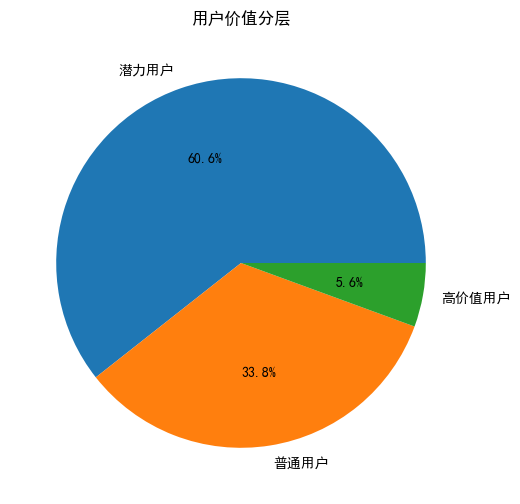

In [25]:
level_count = (
    user_profile["level"]
    .value_counts()
)


plt.figure(
    figsize=(6,6)
)


plt.pie(
    level_count.values,
    labels=level_count.index,
    autopct="%1.1f%%"
)


plt.title(
    "用户价值分层"
)


plt.show()

In [26]:
pv_df = df[
    df["behavior"]=="pv"
]

In [27]:
top10_items = (
    pv_df
    .groupby("item_id")
    .size()
    .sort_values(
        ascending=False
    )
    .head(10)
    .reset_index()
)


top10_items.columns=[
    "item_id",
    "pv_count"
]


top10_items

,item_id,pv_count
0,812879,30094
1,3845720,25668
2,138964,21109
3,2331370,19490
4,2032668,19145
5,1535294,17841
6,59883,17409
7,4211339,17354
8,3031354,17182
9,3371523,17159


In [28]:
top10_items.to_csv(
    "../data/top10_items.csv",
    index=False,
    encoding="utf-8-sig"
)

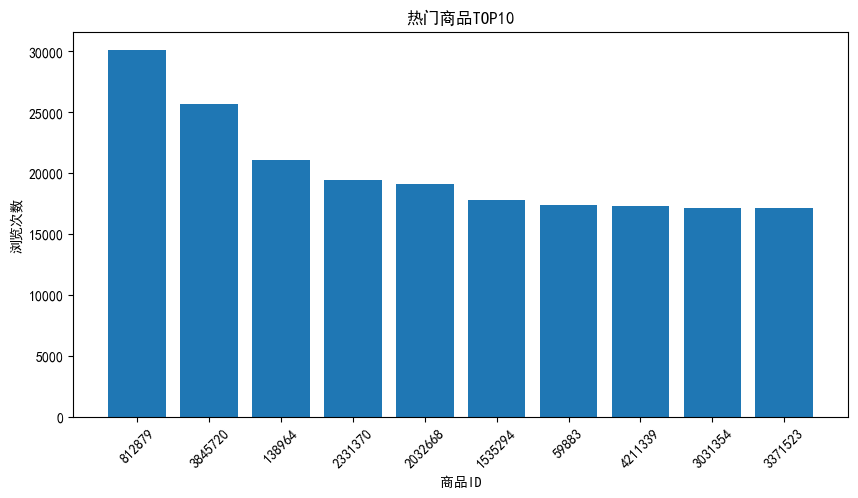

In [29]:
plt.figure(
    figsize=(10,5)
)


plt.bar(
    top10_items["item_id"].astype(str),
    top10_items["pv_count"]
)


plt.xticks(
    rotation=45
)


plt.xlabel(
    "商品ID"
)


plt.ylabel(
    "浏览次数"
)


plt.title(
    "热门商品TOP10"
)


plt.show()